In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

In [2]:
RESULT_DIR = '../affine_denoising_results'

In [3]:
def load_results(npz_file_path, mode):
    data = np.load(npz_file_path, allow_pickle=True)
    
    out = {}
    out['alpha_scales'] = data['alpha_scales'] if "alpha_scales" in data else None
    if out['alpha_scales'] is None:
        raise ValueError("alpha_scales not found in the npz file.")

    out['alpha_scales'] = np.array(out['alpha_scales'], dtype=float)

    for k in ["psnr", "ssim", "sd_psnr", "sd_ssim"]:
        if k in data:
            out[k] = np.array(data[k], dtype=float)
        else:
            out[k] = None
    
    if 'model_name' in data:
        out['model_name'] = str(data['model_name'])
    else:
        raise ValueError("model_name not found in the npz file.")

    out['mode'] = mode
    
    return out


In [4]:
files = {
    "LPN": {
        "brighten": os.path.join(RESULT_DIR, "lpn_brighten_results.npz"),
        "darken": os.path.join(RESULT_DIR, "lpn_darken_results.npz")
    },
    "NE-LPN (By Design)": {
        "brighten": os.path.join(RESULT_DIR, "ne_by_design_brighten_results.npz"),
        "darken": os.path.join(RESULT_DIR, "ne_by_design_darken_results.npz")
    },
    "Scale-Equivariant LPN (By Design)": {
        "brighten": os.path.join(RESULT_DIR, "scale_by_design_brighten_results.npz"),
        "darken": os.path.join(RESULT_DIR, "scale_by_design_darken_results.npz")
    },
    "NE-LPN (By Normalization Trick)": {
        "brighten": os.path.join(RESULT_DIR, "ne_by_forward_brighten_results.npz"),
        "darken": os.path.join(RESULT_DIR, "ne_by_forward_darken_results.npz")
    }
}

In [5]:
series = []
for model_name, modes in files.items():
    for mode, path in modes.items():
        if os.path.exists(path):
            res = load_results(path, mode)
            series.append(res)
        else:
            print(f"WARNING: missing {path}")

In [6]:
def filter_by_mode(series, mode):
    return [s for s in series if s["mode"] == mode]

In [7]:
save_fig = './equivariant_denoising_figures'
os.makedirs(save_fig, exist_ok=True)

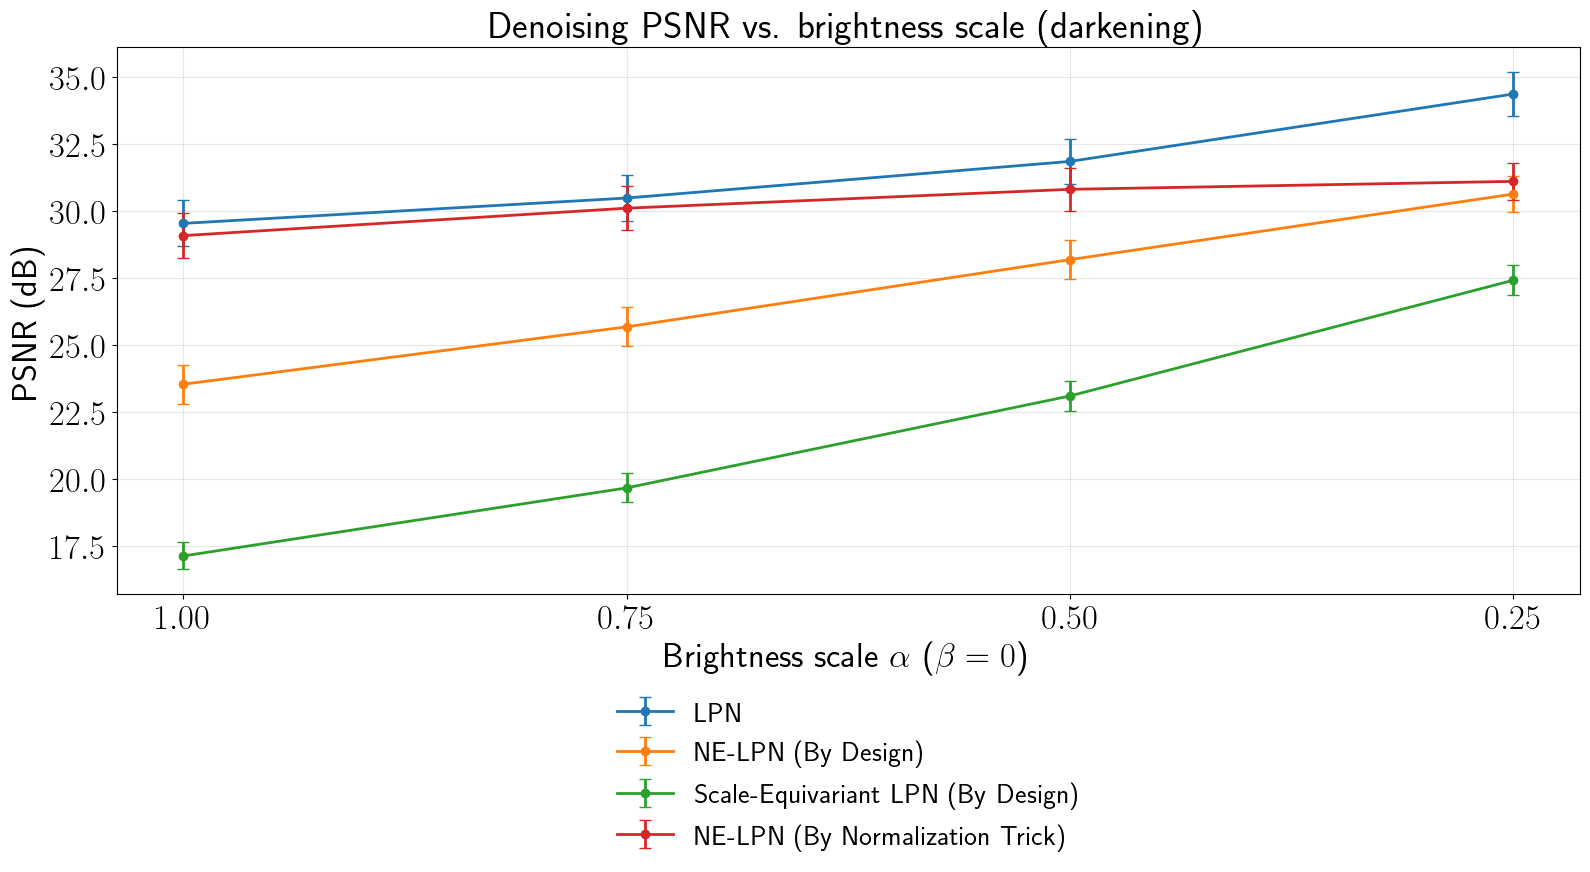

In [8]:
dark = filter_by_mode(series, "darken")
if dark:
    plt.figure(figsize=(16, 8))
    for s in dark:
        x = s["alpha_scales"]
        y = s["psnr"]
        yerr = s["sd_psnr"]
        label = f"{s['model_name']}"
        if yerr is not None:
            plt.errorbar(x, y, yerr=yerr, linewidth=2, marker='o', capsize=4, label=label)
        else:
            plt.plot(x, y, linewidth=2, marker='o', label=label)
    plt.xlabel(r"Brightness scale $\alpha$  ($\beta=0$)", fontsize=25)
    plt.ylabel("PSNR (dB)", fontsize=25)
    plt.title("Denoising PSNR vs. brightness scale (darkening)", fontsize=27, fontweight='bold')
    plt.xticks(x, fontsize=25)
    plt.yticks(fontsize=25)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=20, frameon=False)
    plt.tight_layout(); plt.subplots_adjust(bottom=0.25)
    plt.gca().invert_xaxis()
    plt.savefig(os.path.join(save_fig, "darken_psnrs.pdf"), bbox_inches='tight')
    plt.show()

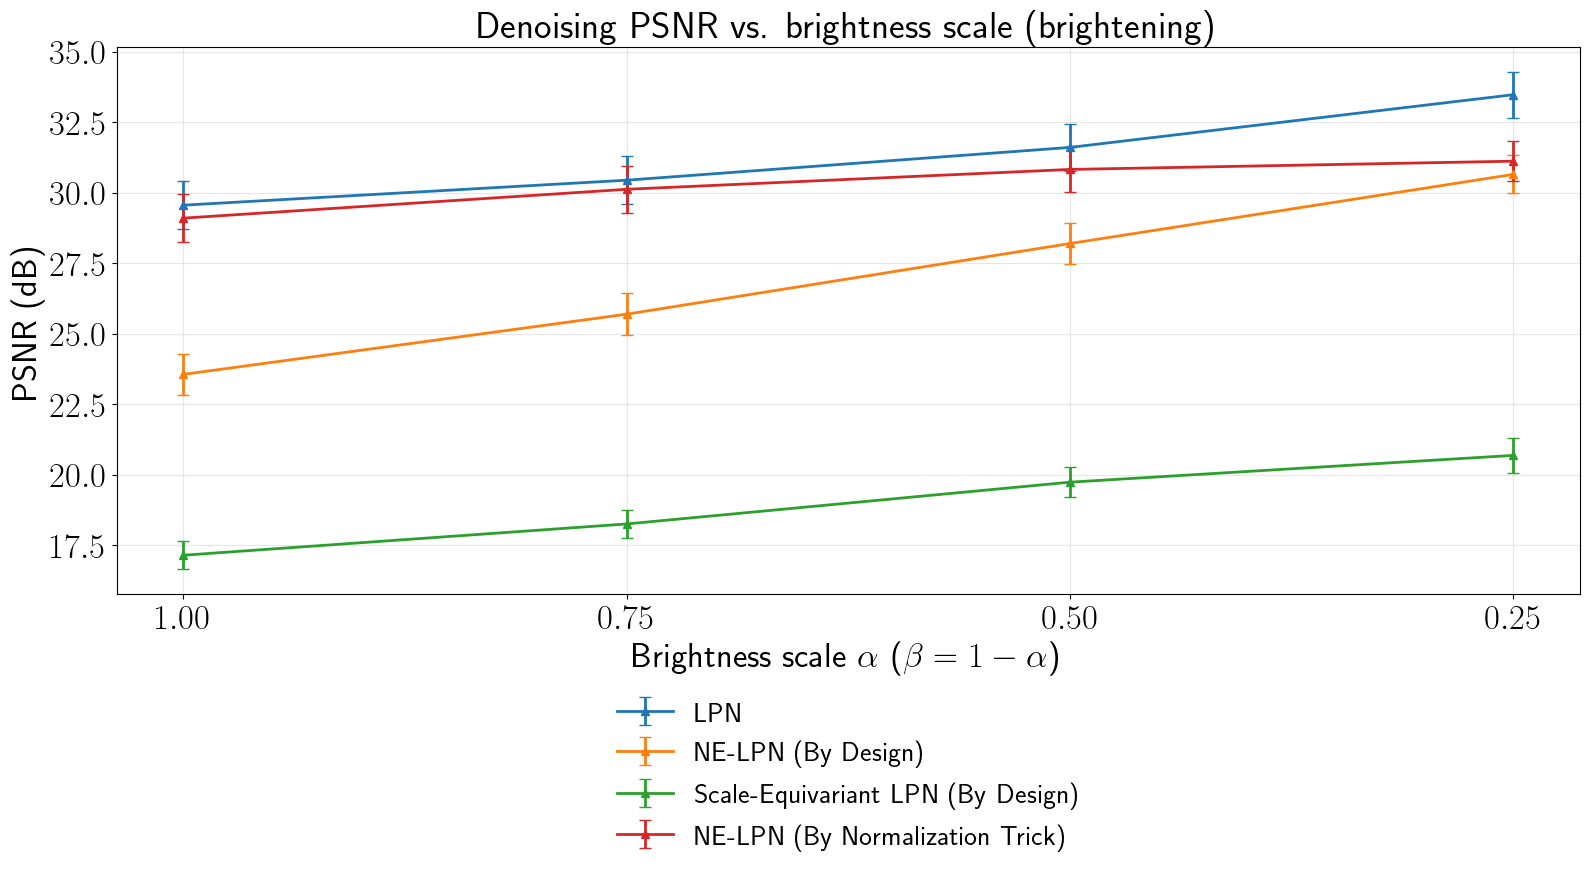

In [9]:
bright = filter_by_mode(series, "brighten")
if bright:
    plt.figure(figsize=(16, 8))
    for s in bright:
        x = s["alpha_scales"]
        y = s["psnr"]
        yerr = s["sd_psnr"]
        label = f"{s['model_name']}"
        if yerr is not None:
            plt.errorbar(x, y, yerr=yerr, linewidth=2, marker='^', capsize=4, label=label)
        else:
            plt.plot(x, y, linewidth=2, marker='^', label=label)
    plt.xlabel(r"Brightness scale $\alpha$  ($\beta=1-\alpha$)", fontsize=25)
    plt.ylabel("PSNR (dB)", fontsize=25)
    plt.title("Denoising PSNR vs. brightness scale (brightening)", fontsize=27, fontweight='bold')
    plt.xticks(x, fontsize=25); plt.yticks(fontsize=25)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=20, frameon=False)
    plt.tight_layout(); plt.subplots_adjust(bottom=0.25)
    plt.gca().invert_xaxis()
    plt.savefig(os.path.join(save_fig, "brighten_psnrs.pdf"), bbox_inches='tight')
    plt.show()